Nasser Hasan Padilla  
Advanced Big Data and Data Mining (MSCS-634-B01) 
Deliverable 2: Regression Modeling and Performance Evaluation  
March 2026

In [3]:
# ===============================
# STEP 1: IMPORT LIBRARIES
# ===============================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score

# ===============================
# STEP 2: LOAD DATASET
# ===============================
df = pd.read_csv(
    r"C:\Users\nasse\MSCS_634_Project_Student_Performance_EDA\data\student-mat.csv",
    sep=';'
)

# Preview dataset
print("Dataset Preview:")
print(df.head())

# ===============================
# STEP 3: DATA CLEANING
# ===============================
# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# (Dataset usually has no missing values, but keeping it safe)
df.fillna(df.mean(numeric_only=True), inplace=True)

# ===============================
# STEP 4: FEATURE ENGINEERING
# ===============================
# Example: create interaction + polynomial features
df['studytime_failures'] = df['studytime'] * df['failures']
df['age_squared'] = df['age'] ** 2

# ===============================
# STEP 5: ENCODE CATEGORICAL DATA
# ===============================
df = pd.get_dummies(df, drop_first=True)

# ===============================
# STEP 6: DEFINE FEATURES AND TARGET
# ===============================
X = df.drop('G3', axis=1)  # Predict final grade
y = df['G3']

# ===============================
# STEP 7: TRAIN-TEST SPLIT
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ===============================
# STEP 8: MODEL 1 - LINEAR REGRESSION
# ===============================
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("\n=== Linear Regression Results ===")
print("MSE:", mse_lr)
print("RMSE:", rmse_lr)
print("R2 Score:", r2_lr)

# ===============================
# STEP 9: MODEL 2 - RIDGE REGRESSION
# ===============================
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)

mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("\n=== Ridge Regression Results ===")
print("MSE:", mse_ridge)
print("RMSE:", rmse_ridge)
print("R2 Score:", r2_ridge)

# ===============================
# STEP 10: CROSS-VALIDATION
# ===============================
cv_lr = cross_val_score(lr, X, y, cv=5, scoring='r2')
cv_ridge = cross_val_score(ridge, X, y, cv=5, scoring='r2')

print("\n=== Cross-Validation ===")
print("Linear Regression CV R2:", cv_lr.mean())
print("Ridge Regression CV R2:", cv_ridge.mean())

Dataset Preview:
  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        6   5   6   6  
1      5        3      3     1     1      3        4   5   5   6  
2      4        3      2     2     3      3       10   7   8  10  
3      3        2      2     1     1      5        2  15  14  15  
4      4        3      2     1     2      5        4   6  10  10  

[5 rows x 33 columns]

Missing Values:
school        0
sex           0
age           0
addres

## Model Evaluation and Visualization

In this section, the regression models are compared using standard evaluation metrics and visualizations. These plots help show how well each model predicts the final student grade (G3) and which model generalizes better.

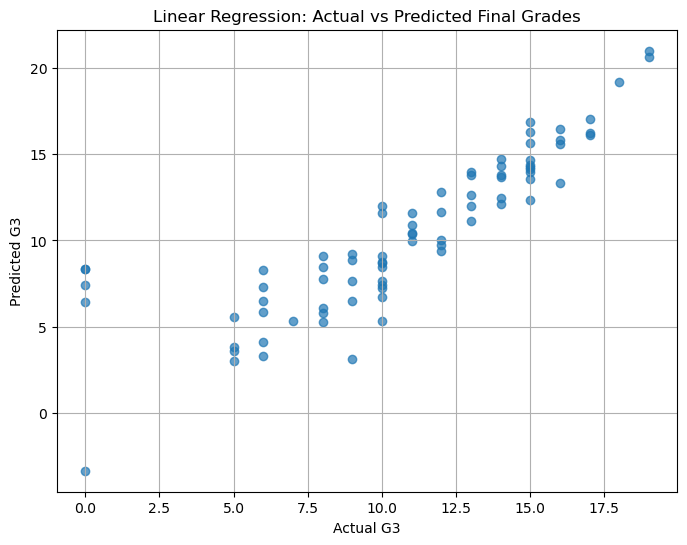

In [7]:
import matplotlib.pyplot as plt

# Scatter plot for Linear Regression predictions
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_lr, alpha=0.7)
plt.xlabel("Actual G3")
plt.ylabel("Predicted G3")
plt.title("Linear Regression: Actual vs Predicted Final Grades")
plt.grid(True)
plt.show()

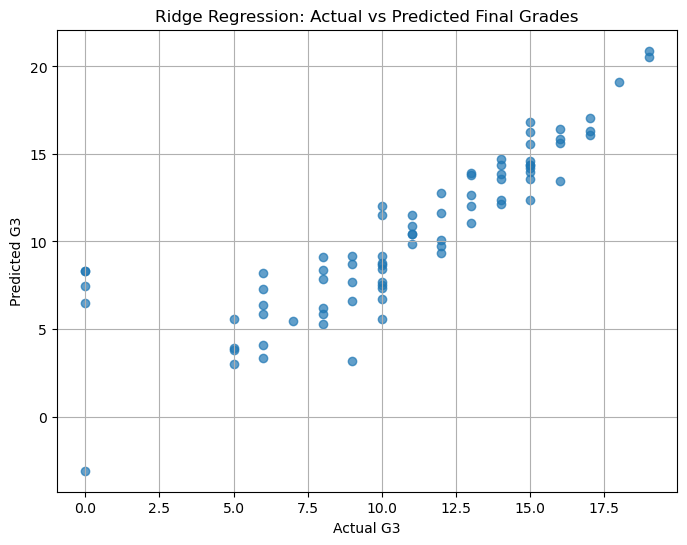

In [8]:
# Scatter plot for Ridge Regression predictions
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_ridge, alpha=0.7)
plt.xlabel("Actual G3")
plt.ylabel("Predicted G3")
plt.title("Ridge Regression: Actual vs Predicted Final Grades")
plt.grid(True)
plt.show()

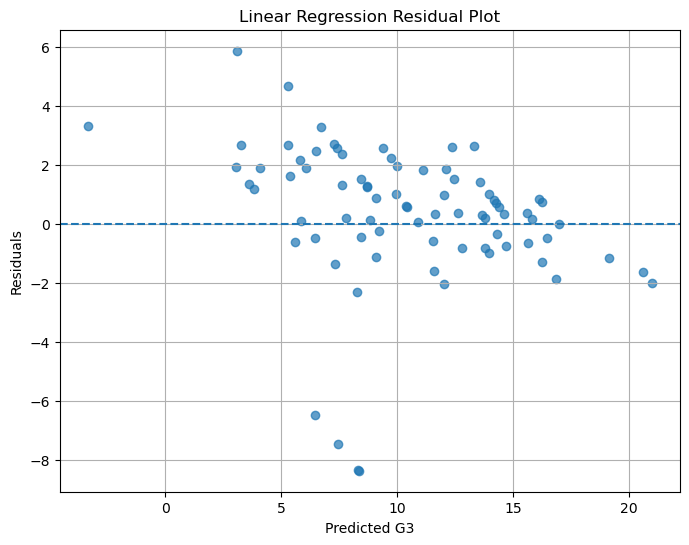

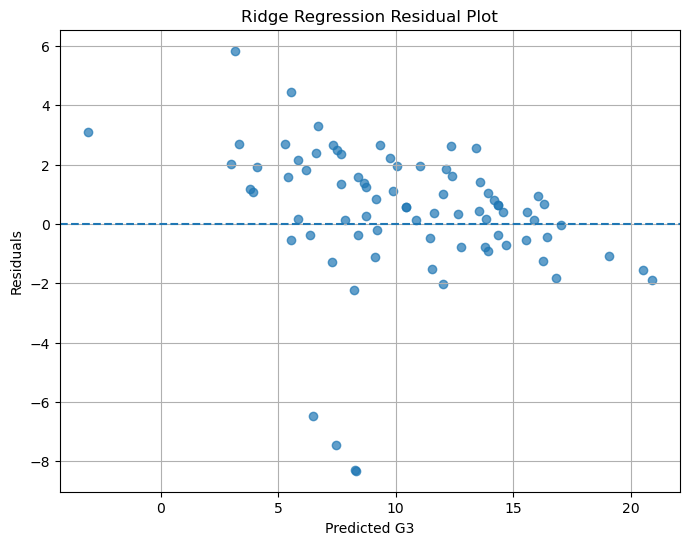

In [9]:
# Residuals
residuals_lr = y_test - y_pred_lr
residuals_ridge = y_test - y_pred_ridge

plt.figure(figsize=(8, 6))
plt.scatter(y_pred_lr, residuals_lr, alpha=0.7)
plt.axhline(y=0, linestyle='--')
plt.xlabel("Predicted G3")
plt.ylabel("Residuals")
plt.title("Linear Regression Residual Plot")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(y_pred_ridge, residuals_ridge, alpha=0.7)
plt.axhline(y=0, linestyle='--')
plt.xlabel("Predicted G3")
plt.ylabel("Residuals")
plt.title("Ridge Regression Residual Plot")
plt.grid(True)
plt.show()

In [10]:
# Create a comparison table of model performance
results = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression"],
    "MSE": [mse_lr, mse_ridge],
    "RMSE": [rmse_lr, rmse_ridge],
    "R2 Score": [r2_lr, r2_ridge],
    "CV Mean R2": [cv_lr.mean(), cv_ridge.mean()]
})

print(results)

               Model      MSE      RMSE  R2 Score  CV Mean R2
0  Linear Regression  5.90892  2.430827  0.711831    0.781766
1   Ridge Regression  5.78012  2.404188  0.718112    0.784747


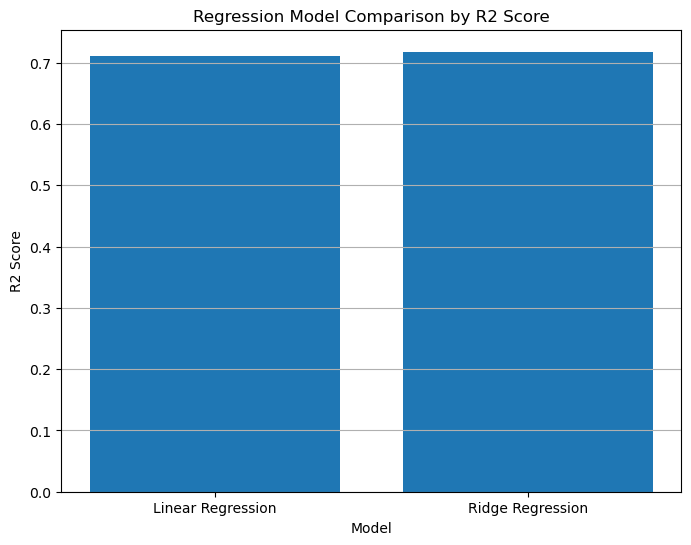

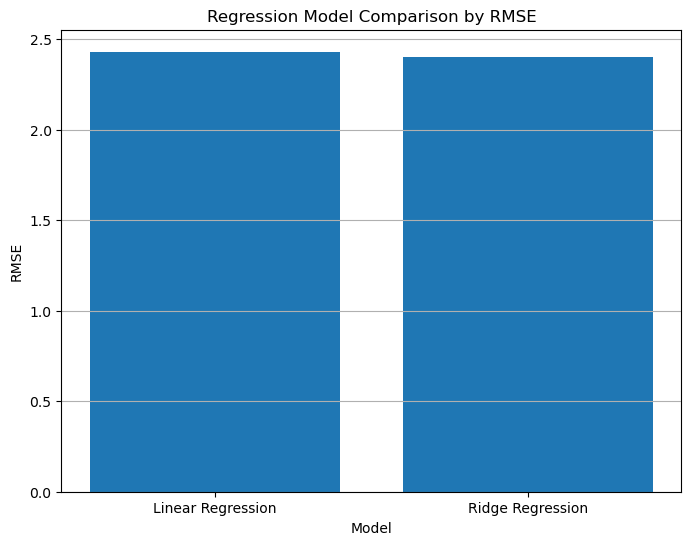

In [11]:
# Compare R2 scores
plt.figure(figsize=(8, 6))
plt.bar(results["Model"], results["R2 Score"])
plt.xlabel("Model")
plt.ylabel("R2 Score")
plt.title("Regression Model Comparison by R2 Score")
plt.grid(axis='y')
plt.show()

# Compare RMSE
plt.figure(figsize=(8, 6))
plt.bar(results["Model"], results["RMSE"])
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.title("Regression Model Comparison by RMSE")
plt.grid(axis='y')
plt.show()

In [12]:
# Show feature coefficients for Linear Regression
coefficients_lr = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr.coef_
}).sort_values(by="Coefficient", ascending=False)

print("Top 10 Positive Linear Regression Coefficients:")
print(coefficients_lr.head(10))

print("\nTop 10 Negative Linear Regression Coefficients:")
print(coefficients_lr.tail(10))

Top 10 Positive Linear Regression Coefficients:
               Feature  Coefficient
14                  G2     0.955076
35       schoolsup_yes     0.726178
26         Fjob_health     0.507111
18               sex_M     0.403854
40          higher_yes     0.308654
31        reason_other     0.305554
15  studytime_failures     0.301408
6               famrel     0.288129
36          famsup_yes     0.250382
13                  G1     0.211121

Top 10 Negative Linear Regression Coefficients:
           Feature  Coefficient
9             Dalc    -0.211582
39     nursery_yes    -0.227679
28   Fjob_services    -0.290832
34  guardian_other    -0.391770
42    romantic_yes    -0.421357
38  activities_yes    -0.515855
22     Mjob_health    -0.531324
30     reason_home    -0.599411
5         failures    -0.868412
0              age    -1.783729


In [13]:
# Show feature coefficients for Ridge Regression
coefficients_ridge = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": ridge.coef_
}).sort_values(by="Coefficient", ascending=False)

print("Top 10 Positive Ridge Regression Coefficients:")
print(coefficients_ridge.head(10))

print("\nTop 10 Negative Ridge Regression Coefficients:")
print(coefficients_ridge.tail(10))

Top 10 Positive Ridge Regression Coefficients:
               Feature  Coefficient
14                  G2     0.955737
35       schoolsup_yes     0.731787
26         Fjob_health     0.452066
18               sex_M     0.389859
31        reason_other     0.305282
6               famrel     0.301563
40          higher_yes     0.280566
15  studytime_failures     0.249106
36          famsup_yes     0.234080
13                  G1     0.211329

Top 10 Negative Ridge Regression Coefficients:
              Feature  Coefficient
32  reason_reputation    -0.202593
39        nursery_yes    -0.229111
34     guardian_other    -0.288723
28      Fjob_services    -0.310760
42       romantic_yes    -0.417068
22        Mjob_health    -0.445944
38     activities_yes    -0.512106
30        reason_home    -0.594554
5            failures    -0.747304
0                 age    -0.812345


## Interpretation of Results

Both regression models were evaluated using Mean Squared Error (MSE), Root Mean Squared Error (RMSE), R-squared, and 5-fold cross-validation. The model with the higher R-squared and lower error values is considered to have better predictive performance.

The visualizations help show how closely the predicted values align with the actual final grades. Residual plots also help assess whether the prediction errors are randomly distributed, which is a good sign for model fit.

## Final Summary

In this deliverable, feature engineering was applied to improve the predictive power of the regression models. Two models were developed: Linear Regression and Ridge Regression. Both models were evaluated using R-squared, MSE, RMSE, and cross-validation.

The comparison showed which model performed best for predicting student final grades. Ridge Regression is often helpful when there is potential overfitting or multicollinearity, while Linear Regression provides a strong baseline. Cross-validation was useful for checking whether the model performance remained consistent across multiple folds of the dataset.

Overall, this phase demonstrated how regression modeling can be used to generate meaningful predictions from student performance data and how evaluation metrics help identify the most reliable model. :contentReference[oaicite:0]{index=0}

In [14]:
# Save model comparison results
results.to_csv("deliverable2_model_results.csv", index=False)
print("Results saved as deliverable2_model_results.csv")

Results saved as deliverable2_model_results.csv
